In [1]:
# Install libraries
!pip install imbalanced-learn xgboost openpyxl

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

from google.colab import files

# ================= LOAD DATA =================
df = pd.read_excel("/content/PCOS_data_without_infertility.xlsx", sheet_name="Full_new")

df.drop(columns=["Sl. No", "Patient File No.", "Unnamed: 44"], inplace=True, errors="ignore")

# Fill missing values
for col in df.columns:
    if df[col].dtype != "object":
        df[col].fillna(df[col].median(), inplace=True)

# ================= SPLIT FEATURES & TARGET =================
X = df.drop("PCOS (Y/N)", axis=1)
y = df["PCOS (Y/N)"].astype(int)

# Keep original test data for final CSV
X_original = X.copy()

# ================= TRAIN TEST SPLIT =================
X_train, X_test, y_train, y_test, X_train_orig, X_test_orig = train_test_split(
    X, y, X_original,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Fill NaN using training median
for col in X_train.columns:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

# ================= SCALING =================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================= SMOTE =================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# ================= MODEL =================
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_smote, y_train_smote)

# ================= PREDICTIONS =================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ================= RISK CATEGORY FUNCTION =================
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Moderate Risk"
    else:
        return "High Risk"

risk_labels = [risk_category(p) for p in y_prob]

# ================= CREATE FINAL CSV =================
prediction_df = X_test_orig.copy()

prediction_df["Actual_PCOS"] = y_test.values
prediction_df["Predicted_PCOS"] = y_pred
prediction_df["PCOS_Probability"] = y_prob
prediction_df["Risk_Category"] = risk_labels

# ================= SAVE CSV =================
prediction_df.to_csv("PCOS_Prediction_Output.csv", index=False)

print("✅ Prediction CSV Created")

# ================= DOWNLOAD CSV =================
files.download("PCOS_Prediction_Output.csv")

# ================= SAVE MODEL =================
joblib.dump(model, "pcos_model.pkl")
joblib.dump(scaler, "pcos_scaler.pkl")

files.download("pcos_model.pkl")
files.download("pcos_scaler.pkl")


/tmp/ipython-input-138/2354992027.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-138/2354992027.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

Accuracy: 0.926605504587156
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        73
           1       0.94      0.83      0.88        36

    accuracy                           0.93       109
   macro avg       0.93      0.90      0.91       109
weighted avg       0.93      0.93      0.93       109

✅ Prediction CSV Created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

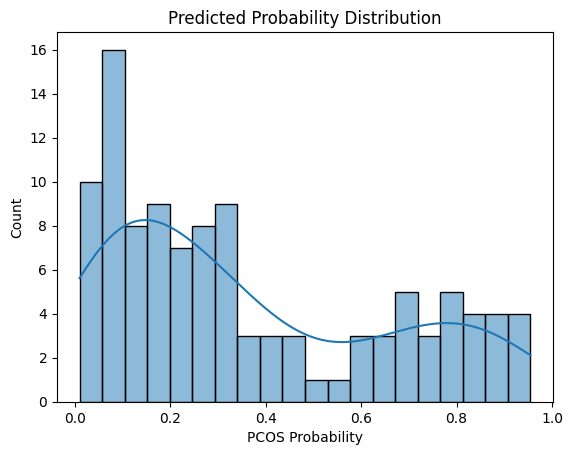

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_prob, bins=20, kde=True)
plt.title("Predicted Probability Distribution")
plt.xlabel("PCOS Probability")
plt.show()

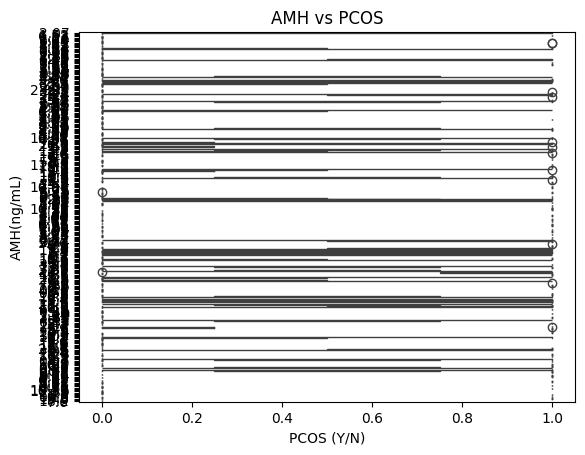

In [4]:
sns.boxplot(x=y, y=df["AMH(ng/mL)"])
plt.title("AMH vs PCOS")
plt.show()

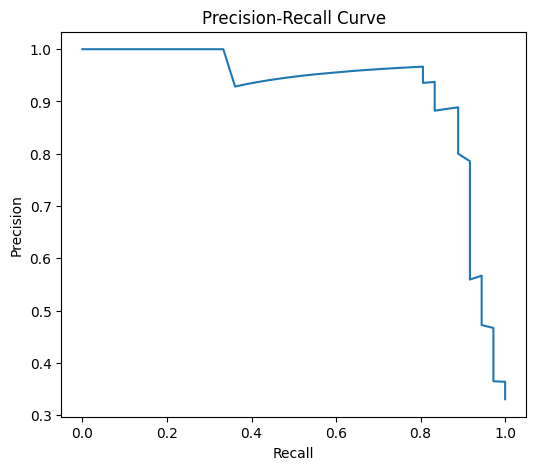

In [5]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

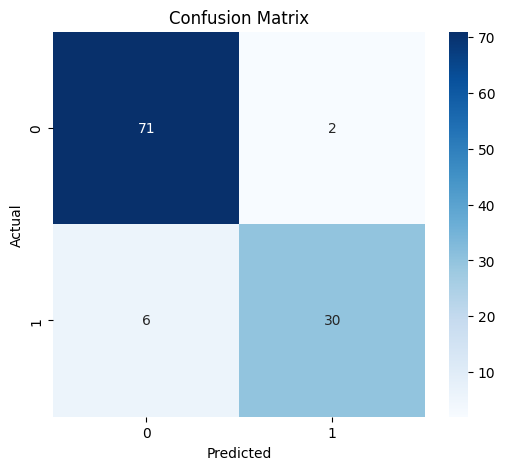

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()